In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
customers = pd.read_csv("../data/tb_cust.csv")
transactions = pd.read_csv("../data/tb_transaction.csv")
fees = pd.read_csv("../data/tb_transaction_fees.csv")

In [7]:
customers["registration_date"] = pd.to_datetime(
    customers["registration_date"]
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [8]:
segment_counts = customers["customer_segment"].value_counts()

segment_counts

customer_segment
Office Worker          3892
College Student        3561
High School Student    2547
Name: count, dtype: int64

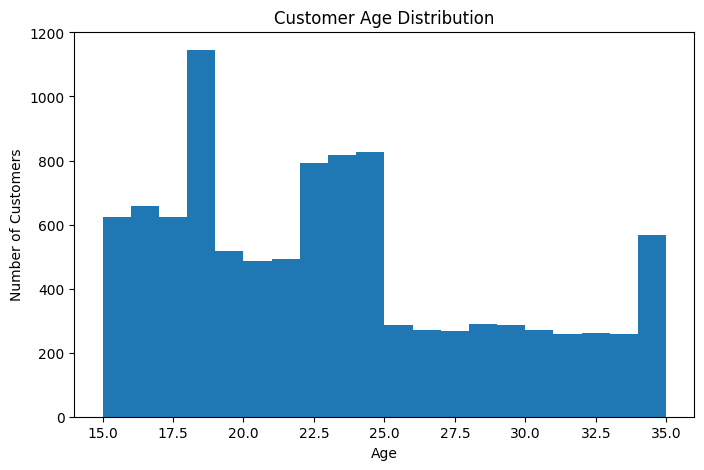

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(
    customers["age"],
    bins=20
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

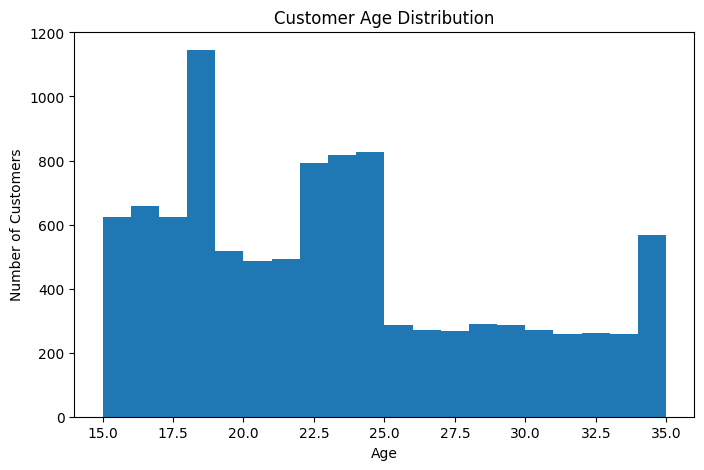

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(
    customers["age"],
    bins=20
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [11]:
customers.groupby(
    "customer_segment"
)["age"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
customer_segment,,,,,
College Student,3561,21.042123,21.0,18,24
High School Student,2547,16.502945,16.0,15,18
Office Worker,3892,28.399281,28.0,22,35


In [12]:
customer_activity = (
    transactions
    .groupby("customer_id")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        average_transaction_value=("amount", "mean"),
        last_transaction_date=("transaction_date", "max")
    )
    .reset_index()
)

In [13]:
customer_activity.head()

,customer_id,transaction_count,total_transaction_value,average_transaction_value,last_transaction_date
0,1,19,4909381.78,258388.514737,2026-05-15 10:00:00
1,2,1,305778.22,305778.220000,2026-03-16 19:00:00
2,3,77,21088919.11,273882.066364,2026-06-26 00:00:00
3,4,3,589722.50,196574.166667,2026-06-25 13:00:00
4,5,6,2044765.13,340794.188333,2026-01-08 14:00:00


In [14]:
active_customers = customer_activity["customer_id"].nunique()

total_customers = customers["customer_id"].nunique()

inactive_customers = total_customers - active_customers

print("Total Customers:", total_customers)
print("Active Customers:", active_customers)
print("Inactive Customers:", inactive_customers)

Total Customers: 10000
Active Customers: 9538
Inactive Customers: 462


In [15]:
activation_rate = (
    active_customers / total_customers * 100
)

print(f"Customer Activation Rate: {activation_rate:.2f}%")

Customer Activation Rate: 95.38%


In [16]:
top_frequency = (
    customer_activity
    .sort_values(
        "transaction_count",
        ascending=False
    )
    .head(10)
)

top_frequency

,customer_id,transaction_count,total_transaction_value,average_transaction_value,last_transaction_date
6610,6936,173,58192855.62,336374.887977,2026-06-30 00:00:00
890,941,167,52698209.47,315558.140539,2026-06-28 05:00:00
6566,6889,162,49255622.50,304047.052469,2026-06-30 00:00:00
5465,5736,160,45028063.41,281425.396313,2026-06-28 22:00:00
770,815,159,45783184.94,287944.559371,2026-06-25 13:00:00
2353,2474,151,49248544.86,326149.303709,2026-06-25 10:00:00
860,910,150,40198362.26,267989.081733,2026-06-28 21:00:00
3016,3172,147,50224549.89,341663.604694,2026-06-29 08:00:00
4832,5063,144,49850650.29,346185.071458,2026-06-29 06:00:00
5139,5391,138,42028785.85,304556.419203,2026-06-29 18:00:00


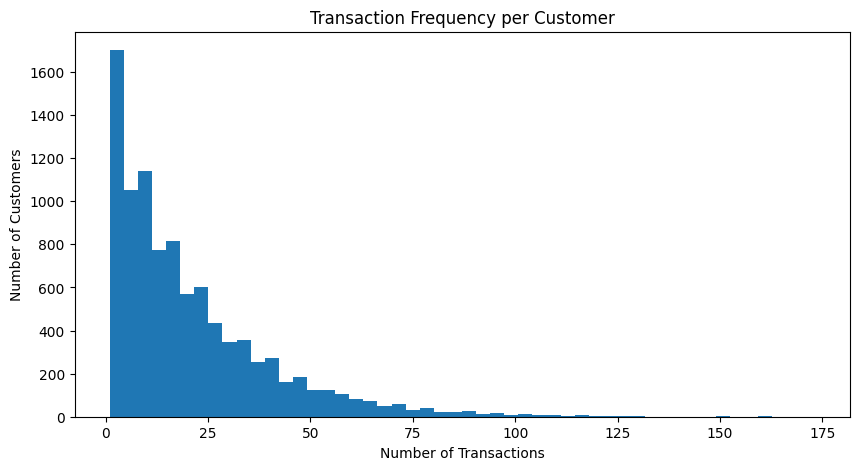

In [17]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer_activity["transaction_count"],
    bins=50
)

plt.title("Transaction Frequency per Customer")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")

plt.show()

In [18]:
customer_revenue = (
    transactions
    .merge(
        fees[["transaction_id", "fee_amount"]],
        on="transaction_id",
        how="left"
    )
    .groupby("customer_id")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount", "sum"),
        total_revenue=("fee_amount", "sum")
    )
    .reset_index()
)

In [19]:
customer_value = customers.merge(
    customer_revenue,
    on="customer_id",
    how="left"
)

customer_value[
    [
        "transaction_count",
        "total_transaction_value",
        "total_revenue"
    ]
] = customer_value[
    [
        "transaction_count",
        "total_transaction_value",
        "total_revenue"
    ]
].fillna(0)

In [20]:
segment_value = (
    customer_value
    .groupby("customer_segment")
    .agg(
        customers=("customer_id", "count"),
        total_transactions=("transaction_count", "sum"),
        total_transaction_value=(
            "total_transaction_value",
            "sum"
        ),
        total_revenue=("total_revenue", "sum")
    )
    .reset_index()
)

segment_value

,customer_segment,customers,total_transactions,total_transaction_value,total_revenue
0,College Student,3561,69646.0,2.142624e+10,1.470695e+08
1,High School Student,2547,51832.0,1.585327e+10,1.091451e+08
2,Office Worker,3892,78522.0,2.422720e+10,1.665448e+08


In [21]:
segment_value["revenue_per_customer"] = (
    segment_value["total_revenue"]
    / segment_value["customers"]
)

In [22]:
segment_value["transaction_value_per_customer"] = (
    segment_value["total_transaction_value"]
    / segment_value["customers"]
)

In [23]:
segment_value

,customer_segment,customers,total_transactions,total_transaction_value,total_revenue,revenue_per_customer,transaction_value_per_customer
0,College Student,3561,69646.0,2.142624e+10,1.470695e+08,41300.060741,6.016917e+06
1,High School Student,2547,51832.0,1.585327e+10,1.091451e+08,42852.401076,6.224291e+06
2,Office Worker,3892,78522.0,2.422720e+10,1.665448e+08,42791.575660,6.224872e+06


In [24]:
segment_value["revenue_contribution_pct"] = (
    segment_value["total_revenue"]
    / segment_value["total_revenue"].sum()
    * 100
)

segment_value[
    [
        "customer_segment",
        "total_revenue",
        "revenue_contribution_pct"
    ]
]

,customer_segment,total_revenue,revenue_contribution_pct
0,College Student,1.470695e+08,34.787995
1,High School Student,1.091451e+08,25.817301
2,Office Worker,1.665448e+08,39.394704


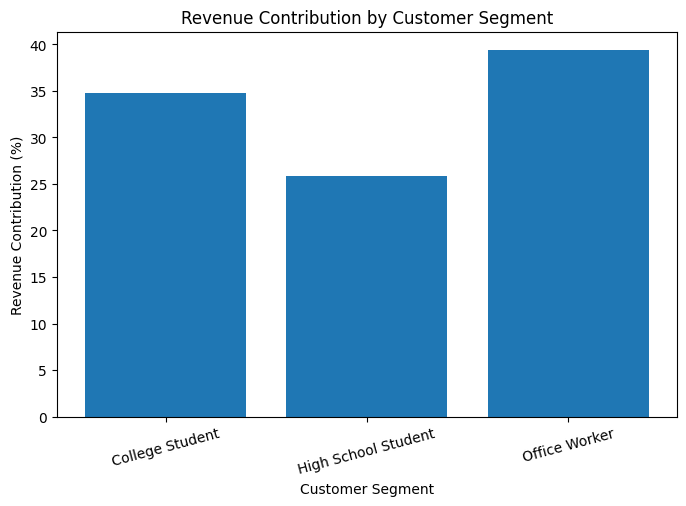

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_value["customer_segment"],
    segment_value["revenue_contribution_pct"]
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue Contribution (%)")

plt.xticks(rotation=15)

plt.show()